In [3]:
import os
from pathlib import Path
from types import SimpleNamespace
from anndata import AnnData
import scanpy as sc

In [4]:
# Add parent directory to path
os.chdir("/workspace/")

# Import STAGM
from src.adata_processing import (
    BatchAdataLoader,
    SingleAdataLoader
)
from src.stagm import STAGM

In [14]:
# Initialize the model configuration with the specified parameters
model_config = SimpleNamespace(
    seed=39788,
    learning_rate=0.0005,
    num_hidden=64,
    num_proj_hidden=64,
    activation="prelu",
    num_layers=1,
    drop_feature_rate_1=0.1,
    drop_feature_rate_2=0.2,
    tau=65,
    num_epochs=800,
    weight_decay=1e-05,
    num_clusters=25,
    num_gene=1111,
    num_neigh=6,
    k=80,
    dropout=0.1,
    shuffle_ind=0,               
    d_state=16,
    d_conv=4,
    order_by_degree=True,
    bidirectional=True
)


# Initialize the dataset configuration with the specified parameters
args = SimpleNamespace(
    dataset="visium", 
    label=False,
    file_list=['Mouse_Brain_Anterior', 'Mouse_Brain_Posterior'],
    slide='integration_horizontal'
)

In [15]:
# Define the base folder and the path to the specific dataset and slide
dataset_path = os.path.join("./Dataset", args.dataset)  # -> "./data/DLPFC"

In [16]:
loader = BatchAdataLoader(
    dataset_path=dataset_path,
    file_list=args.file_list,
    n_top_genes=model_config.num_gene, # 2296 — see note #1 below
    n_neighbors=model_config.num_neigh,# BatchAdataLoader's arg is `n_neighbors`, not `num_neigh`
    image_emb=False,
    label=args.label,                  # True
    # filter_na=True,
    # normalize=True,                    # False if these slices are already normalized/log1p'd
)

adata = loader.run()

now load: Mouse_Brain_Anterior
now load: Mouse_Brain_Posterior
load all slices done
merged feat shape: (6050, 572)
merge done


/workspace/src/adata_processing.py:336: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  merged = concat(self.adata_list, join="outer")
Edge probabilities: 100%|██████████| 6050/6050 [00:00<00:00, 88015.08it/s]

merge adata load done


In [17]:
model_config.num_gene = adata.obsm["feat"].shape[1]
print(model_config.num_gene)

572


In [18]:
# Initialize the STAGM model with the specified parameters and assign the loaded AnnData object to it
stagm = STAGM(args=args, config=model_config, single=True, refine=False)
stagm.adata = adata

In [19]:
stagm.train()

Consider intra slice
=== train ===


100%|██████████| [00:42<00:00, 18.85it/s]


In [20]:
# Evaluate the STAGM model
stagm.eva()

=== load ===

========== Model Diagnostics ==========
  Total parameters:     107,009
  Trainable parameters: 107,009
  Model weight size:    0.41 MB
  Peak GPU memory:      1839.20 MB
  Training time:        0m 42.4s  (42.4s total)
  Time per epoch:       53.0 ms

  Loss curve:            first=8.7095  last=8.6985  min=8.6985  max=8.7095

  Embedding shape:      (6050, 64)
  Embedding norm — mean=2.9232  std=0.8593  min=0.4092  max=5.6496

embedding generated, go clustering


In [21]:
stagm.cluster(args.label)

Searching resolution...
Cluster count 13 is too small, adjusting end upward...
Cluster count 15 is too small, adjusting end upward...
Cluster count 16 is too small, adjusting end upward...
Cluster count 19 is too small, adjusting end upward...
Cluster count 20 is too small, adjusting end upward...
Cluster count 24 is too small, adjusting end upward...
Cluster count 23 is too small, adjusting end upward...
Cluster count 25 is too small, adjusting end upward...
Cluster count 26 is too small, adjusting end upward...
resolution=1.1650, cluster number=29
resolution=1.1600, cluster number=29
resolution=1.1550, cluster number=31
resolution=1.1500, cluster number=31
resolution=1.1450, cluster number=30
resolution=1.1400, cluster number=28
resolution=1.1350, cluster number=30
resolution=1.1300, cluster number=30
resolution=1.1250, cluster number=29
resolution=1.1200, cluster number=29
resolution=1.1150, cluster number=27
resolution=1.1100, cluster number=27
resolution=1.1050, cluster number=28


In [22]:
import seaborn as sns
rgb_values = sns.color_palette("tab20", len(stagm.adata.obs['domain'].unique()))
color_fine = dict(zip(list(stagm.adata.obs['domain'].unique()), rgb_values))

/tmp/ipykernel_36514/869822537.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(stagm.adata, color='domain',palette=color_fine, show=True,save='mouse_domain.pdf')


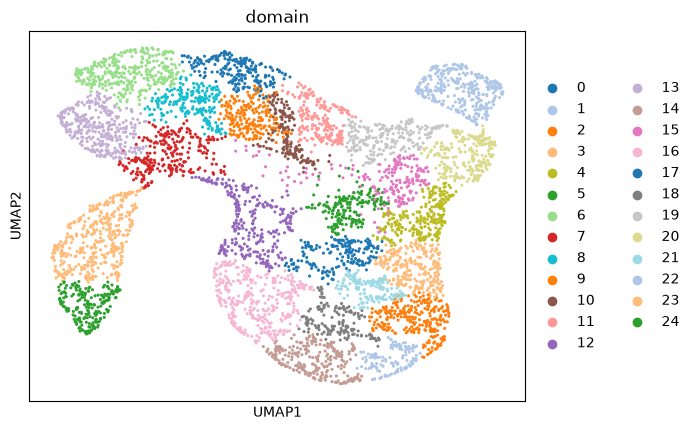

In [23]:
sc.pp.neighbors(stagm.adata, use_rep='emb')
sc.tl.umap(stagm.adata)
sc.pl.umap(stagm.adata, color='domain',palette=color_fine, show=True,save='mouse_domain.pdf')
# sc.pl.umap(stagm.adata, color='batch', show=True,save='mouse_batch.pdf')

/tmp/ipykernel_36514/2113670800.py:4: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  data_all = sc.read_h5ad('./Dataset/9.Mouse_Brain_Merge_Anterior_Posterior_Section_1/filtered_feature_bc_matrix.h5ad') #It merely utilizes already aligned coordinates for better demonstration.
/tmp/ipykernel_36514/2113670800.py:7: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.embedding(stagm.adata, basis="spatial",


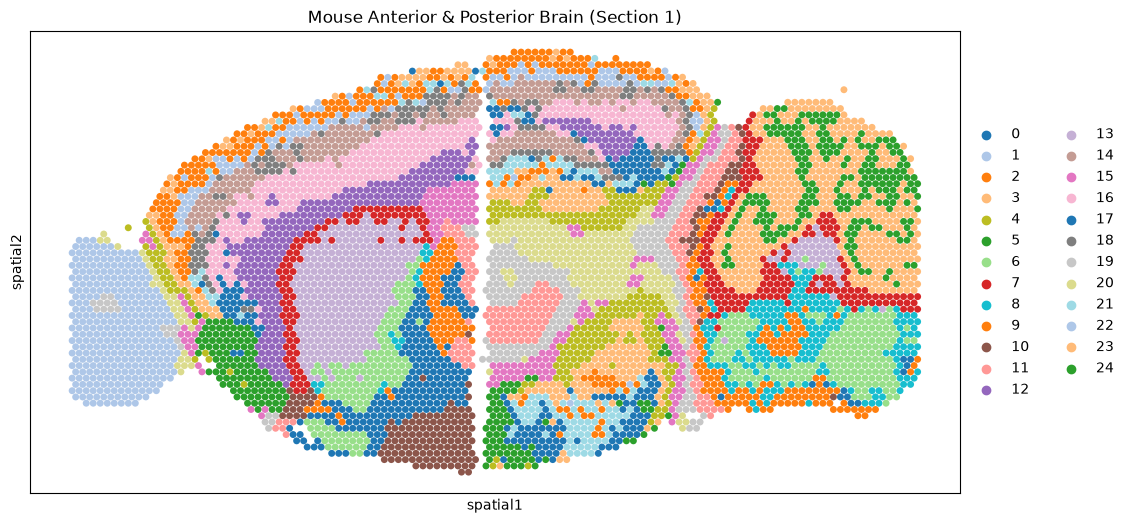

In [24]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)
data_all = sc.read_h5ad('./Dataset/9.Mouse_Brain_Merge_Anterior_Posterior_Section_1/filtered_feature_bc_matrix.h5ad') #It merely utilizes already aligned coordinates for better demonstration.
data_all.obsm['spatial'][:,1] = -1*data_all.obsm['spatial'][:,1]
stagm.adata.obsm['spatial']=data_all.obsm['spatial']
sc.pl.embedding(stagm.adata, basis="spatial",
                    color="domain",save='mouse.pdf',
                    s=100,
                    show=True,
                    palette=color_fine,
                    title='Mouse Anterior & Posterior Brain (Section 1)')